In [4]:
# Import Libraries
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from wordcloud import WordCloud

# Download nltk packages
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
data = {
    "Comments": [
        "I love this new smartphone, amazing features!",
        "The product quality is very poor and disappointing",
        "The price is reasonable but battery life is average",
        "Excellent service, I will recommend this to everyone",
        "Worst experience ever, totally waste of money",
        "The camera quality is awesome",
        "Not satisfied with the customer support",
        "The design looks beautiful and attractive"
    ]
}

df = pd.DataFrame(data)

print("Original Comments")
print(df)

Original Comments
                                            Comments
0      I love this new smartphone, amazing features!
1  The product quality is very poor and disappoin...
2  The price is reasonable but battery life is av...
3  Excellent service, I will recommend this to ev...
4      Worst experience ever, totally waste of money
5                      The camera quality is awesome
6            Not satisfied with the customer support
7          The design looks beautiful and attractive


In [5]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub('[^a-zA-Z]', ' ', text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)


df["Cleaned_Text"] = df["Comments"].apply(clean_text)


print("\nCleaned Text")
print(df)


Cleaned Text
                                            Comments  \
0      I love this new smartphone, amazing features!   
1  The product quality is very poor and disappoin...   
2  The price is reasonable but battery life is av...   
3  Excellent service, I will recommend this to ev...   
4      Worst experience ever, totally waste of money   
5                      The camera quality is awesome   
6            Not satisfied with the customer support   
7          The design looks beautiful and attractive   

                                Cleaned_Text  
0       love new smartphone amazing features  
1         product quality poor disappointing  
2      price reasonable battery life average  
3       excellent service recommend everyone  
4  worst experience ever totally waste money  
5                     camera quality awesome  
6                 satisfied customer support  
7          design looks beautiful attractive  


In [6]:
def sentiment_analysis(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"


df["Sentiment"] = df["Cleaned_Text"].apply(sentiment_analysis)


print("\nSentiment Result")
print(df[["Comments","Sentiment"]])


Sentiment Result
                                            Comments Sentiment
0      I love this new smartphone, amazing features!  Positive
1  The product quality is very poor and disappoin...  Negative
2  The price is reasonable but battery life is av...  Positive
3  Excellent service, I will recommend this to ev...  Positive
4      Worst experience ever, totally waste of money  Negative
5                      The camera quality is awesome  Positive
6            Not satisfied with the customer support  Positive
7          The design looks beautiful and attractive  Positive


In [7]:
all_words = " ".join(df["Cleaned_Text"])

words = all_words.split()

frequency = pd.Series(words).value_counts()

print("\nTrending Topics")
print(frequency.head(10))



Trending Topics
quality          2
love             1
new              1
amazing          1
smartphone       1
features         1
product          1
poor             1
disappointing    1
price            1
Name: count, dtype: int64


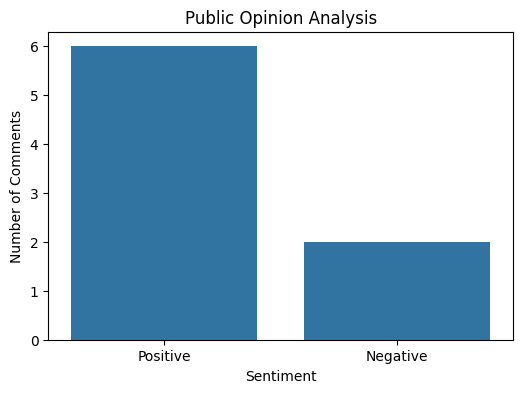

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["Sentiment"]
)

plt.title("Public Opinion Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")

plt.show()



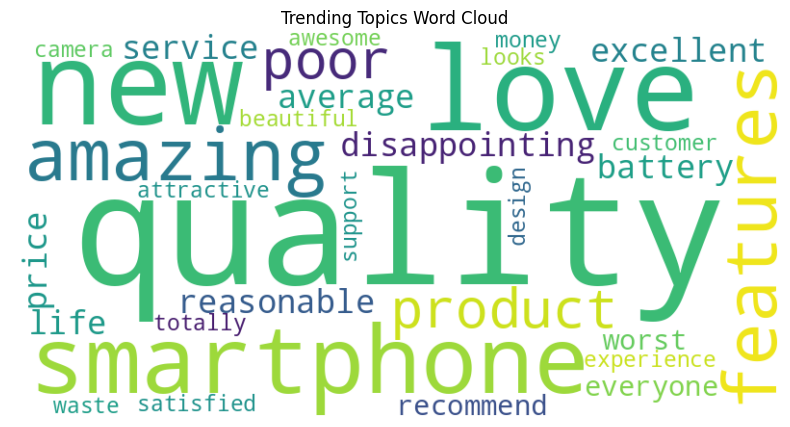

In [9]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)


plt.figure(figsize=(10,5))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Trending Topics Word Cloud")

plt.show()